# **Project Name**    - Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce


##### **Project Type**    - Machine Learning
##### **Contribution**    - Individual
Name: Aditi Soni

# **Project Summary -**

This project, titled “Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce”, focuses on analyzing e-commerce transaction data to understand customer behavior and group customers into meaningful segments. The dataset includes transactional details such as product purchases, quantity, price, and customer identifiers, which are used to study shopping patterns and purchasing frequency.

In the backend (implemented using Python in Google Colab), the project involves data cleaning, preprocessing, and exploratory data analysis to handle missing values, remove inconsistencies, and prepare the dataset for modeling. Customer segmentation is performed using clustering techniques such as K-Means, based on features like purchase frequency, total spending, and recency. This helps in identifying different types of customers such as high-value customers, regular buyers, and occasional shoppers.

In addition to segmentation, the project also includes a recommendation component where similar products or customer preferences are analyzed to suggest relevant items. The insights are visualized using charts and graphs to make patterns easier to understand.

Finally, the frontend dashboard (using Streamlit) provides an interactive interface where users can view customer segments, explore sales patterns, and see product recommendations. Overall, the project demonstrates how data science techniques can be applied in e-commerce to improve customer targeting, personalize recommendations, and support business decision-making.

# **GitHub Link -**

# **Streamlit Link -**

# **Problem Statement**

The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth. This project aims to examine transaction data from an online retail business to uncover patterns in customer purchase behavior, segment customers based on Recency, Frequency, and Monetary (RFM) analysis, and develop a product recommendation system using collaborative filtering techniques.


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
df = pd.read_csv("online_retail.csv")

# Display shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
# Statistical summary
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
# Check missing values

missing_values = df.isnull().sum()

print(missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
# Count duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 5268


In [7]:
# Remove rows where CustomerID is missing

df = df.dropna(subset=['CustomerID'])

print("Shape after removing missing CustomerID:", df.shape)

Shape after removing missing CustomerID: (406829, 8)


In [8]:
# Remove cancelled invoices
# Cancelled invoices start with 'C'

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Shape after removing cancelled invoices:", df.shape)

Shape after removing cancelled invoices: (397924, 8)


In [9]:
# Remove rows with Quantity <= 0
# Remove rows with UnitPrice <= 0

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Shape after removing invalid records:", df.shape)

Shape after removing invalid records: (397884, 8)


In [10]:
# Calculate total transaction amount

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
# Convert InvoiceDate into datetime format

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalAmount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


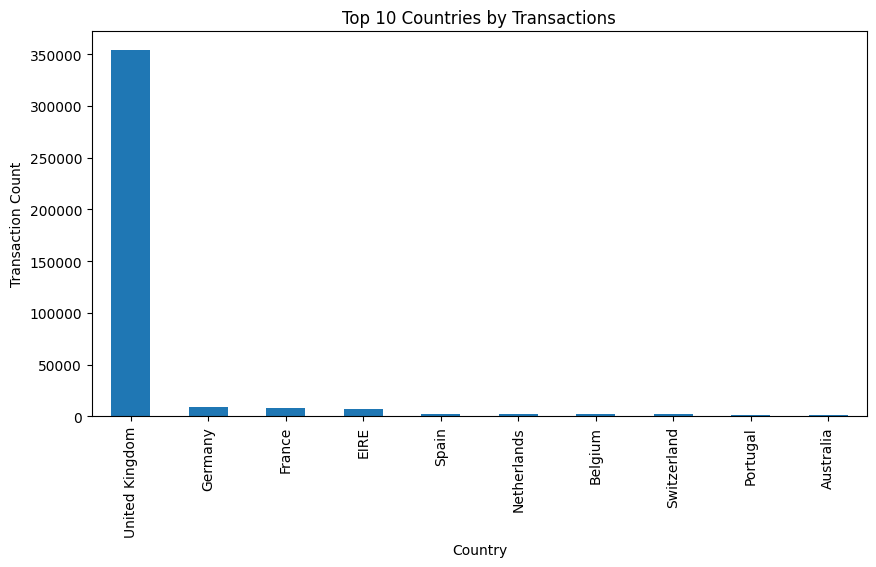

In [12]:
# Top countries by transaction count

country_transactions = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
country_transactions.plot(kind='bar')

plt.title("Top 10 Countries by Transactions")
plt.xlabel("Country")
plt.ylabel("Transaction Count")

plt.show()

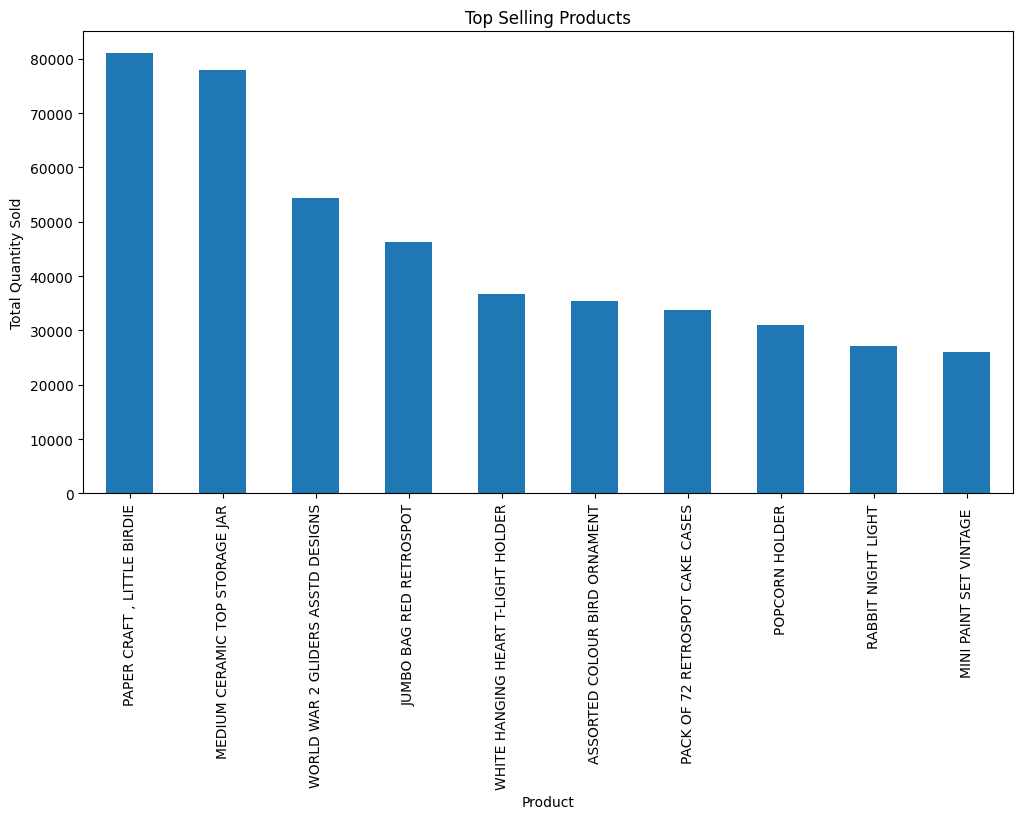

In [13]:
# Top 10 products

top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.show()

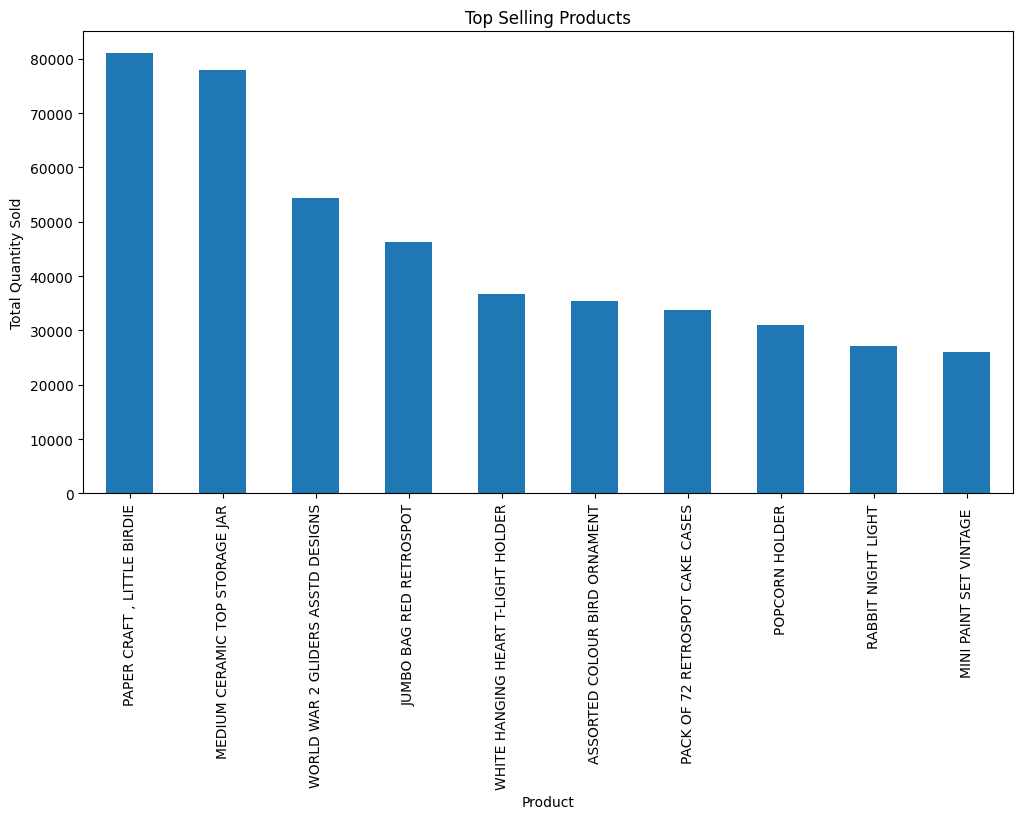

In [14]:
# Top 10 products

top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.show()

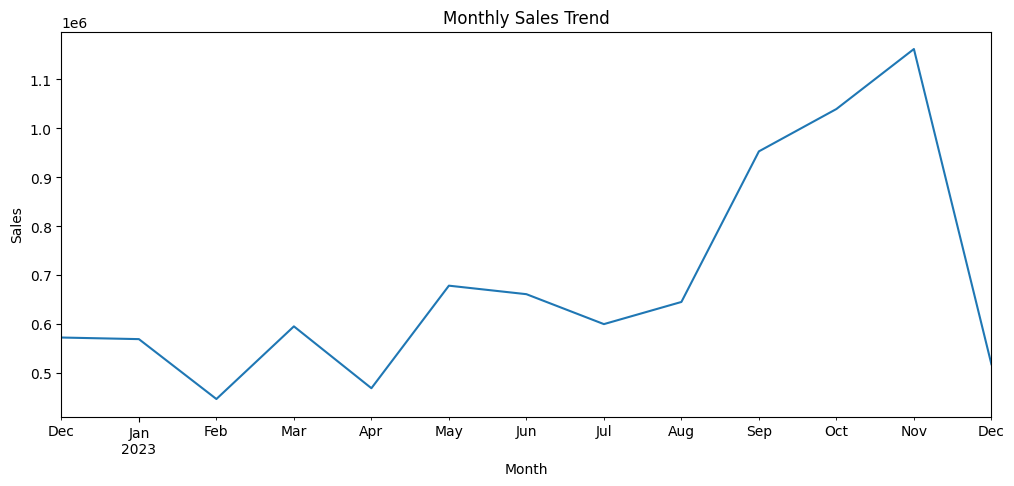

In [15]:
# Create Month column

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['TotalAmount']
    .sum()
)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

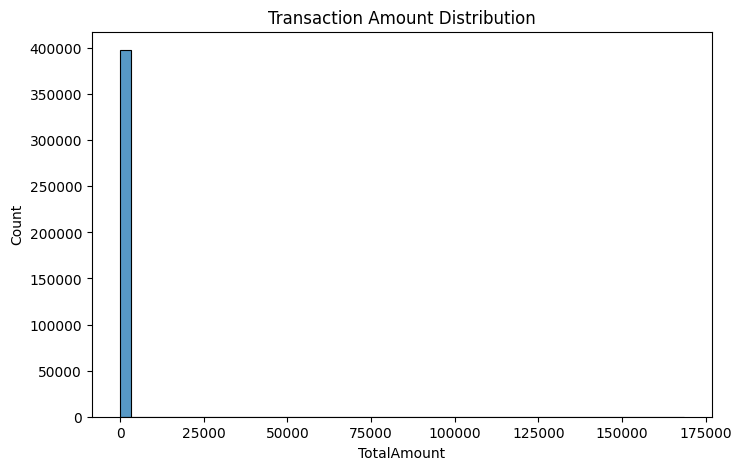

In [16]:
# Distribution of transaction amount

plt.figure(figsize=(8,5))

sns.histplot(df['TotalAmount'], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

In [17]:
# Latest date in dataset

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-12-10 12:50:00


In [18]:
# Calculate Recency, Frequency and Monetary

rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'TotalAmount': 'sum'

})

# Rename columns

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


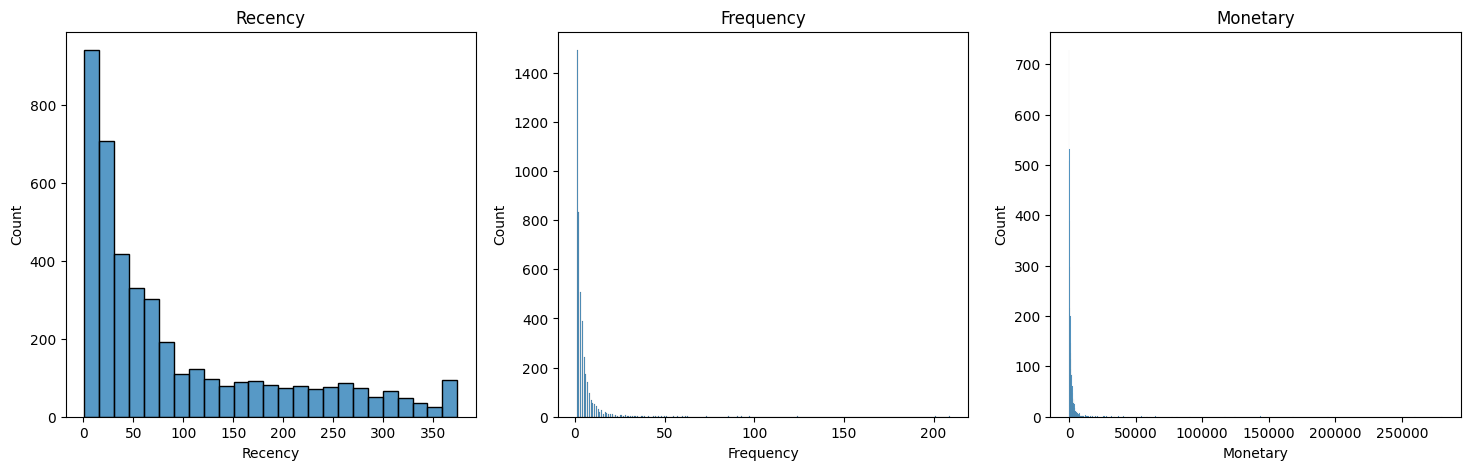

In [19]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(rfm['Recency'], ax=axes[0])
axes[0].set_title("Recency")

sns.histplot(rfm['Frequency'], ax=axes[1])
axes[1].set_title("Frequency")

sns.histplot(rfm['Monetary'], ax=axes[2])
axes[2].set_title("Monetary")

plt.show()

In [20]:
# Scale features

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

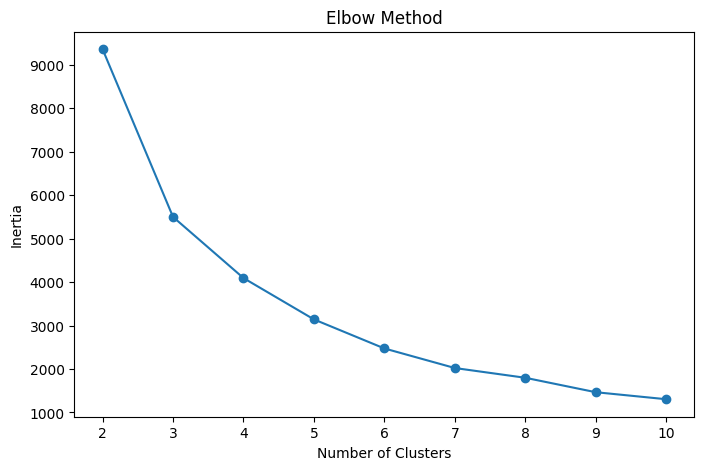

In [21]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [22]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print("K =",k,
          "Silhouette Score =",score)

K = 2 Silhouette Score = 0.5603671809121974
K = 3 Silhouette Score = 0.5852924318247733
K = 4 Silhouette Score = 0.616212846765192
K = 5 Silhouette Score = 0.617115186725246
K = 6 Silhouette Score = 0.5982715957283189
K = 7 Silhouette Score = 0.51717221452567
K = 8 Silhouette Score = 0.49091567183009177
K = 9 Silhouette Score = 0.484017028247486
K = 10 Silhouette Score = 0.42503454870703994


In [23]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [24]:
cluster_profile = rfm.groupby('Cluster')[

    ['Recency',
     'Frequency',
     'Monetary']

].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


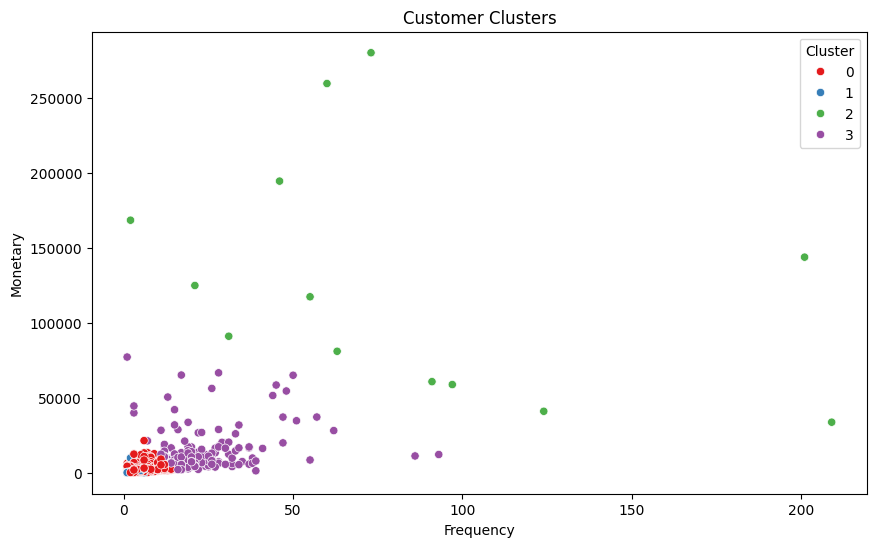

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Clusters")

plt.show()

In [26]:
cluster_mapping = {

    0 : "High-Value",
    1 : "Regular",
    2 : "Occasional",
    3 : "At-Risk"

}

rfm['Segment'] = rfm['Cluster'].map(
    cluster_mapping
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,At-Risk
12347.0,2,7,4310.00,0,High-Value
12348.0,75,4,1797.24,0,High-Value
12349.0,19,1,1757.55,0,High-Value
12350.0,310,1,334.40,1,Regular


In [27]:
customer_product_matrix = pd.pivot_table(

    df,

    index='CustomerID',

    columns='Description',

    values='Quantity',

    aggfunc='sum',

    fill_value=0

)

customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
product_matrix = customer_product_matrix.T

similarity = cosine_similarity(product_matrix)

similarity_df = pd.DataFrame(

    similarity,

    index=product_matrix.index,

    columns=product_matrix.index

)

similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000227,0.000000,0.000000,0.020155,0.000000,0.000262,0.063396,...,0.0,0.001368,0.015886,0.001767,0.0,0.002846,0.0,0.013128,0.000000,0.002594
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003533,0.004001,0.000000,0.020034,0.027433,0.900849,0.119031,0.013380,...,0.0,0.001718,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003533,1.000000,0.870851,0.980561,0.006296,0.005302,0.003034,0.001765,0.411331,...,0.0,0.000043,0.002869,0.344923,0.0,0.525860,0.0,0.822946,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000227,0.004001,0.870851,1.000000,0.883883,0.019879,0.004904,0.004043,0.008270,0.382056,...,0.0,0.001409,0.004197,0.310017,0.0,0.471717,0.0,0.749210,0.000000,0.010393
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980561,0.883883,1.000000,0.000000,0.000000,0.000000,0.000000,0.410578,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837170,0.000000,0.000000


In [29]:
def recommend_products(product_name):

    if product_name not in similarity_df.index:

        return ["Product Not Found"]

    similar_products = (

        similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:6]

    )

    return similar_products.index.tolist()

In [30]:
recommend_products(
    "WHITE HANGING HEART T-LIGHT HOLDER"
)

['GIN + TONIC DIET METAL SIGN',
 'RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER']

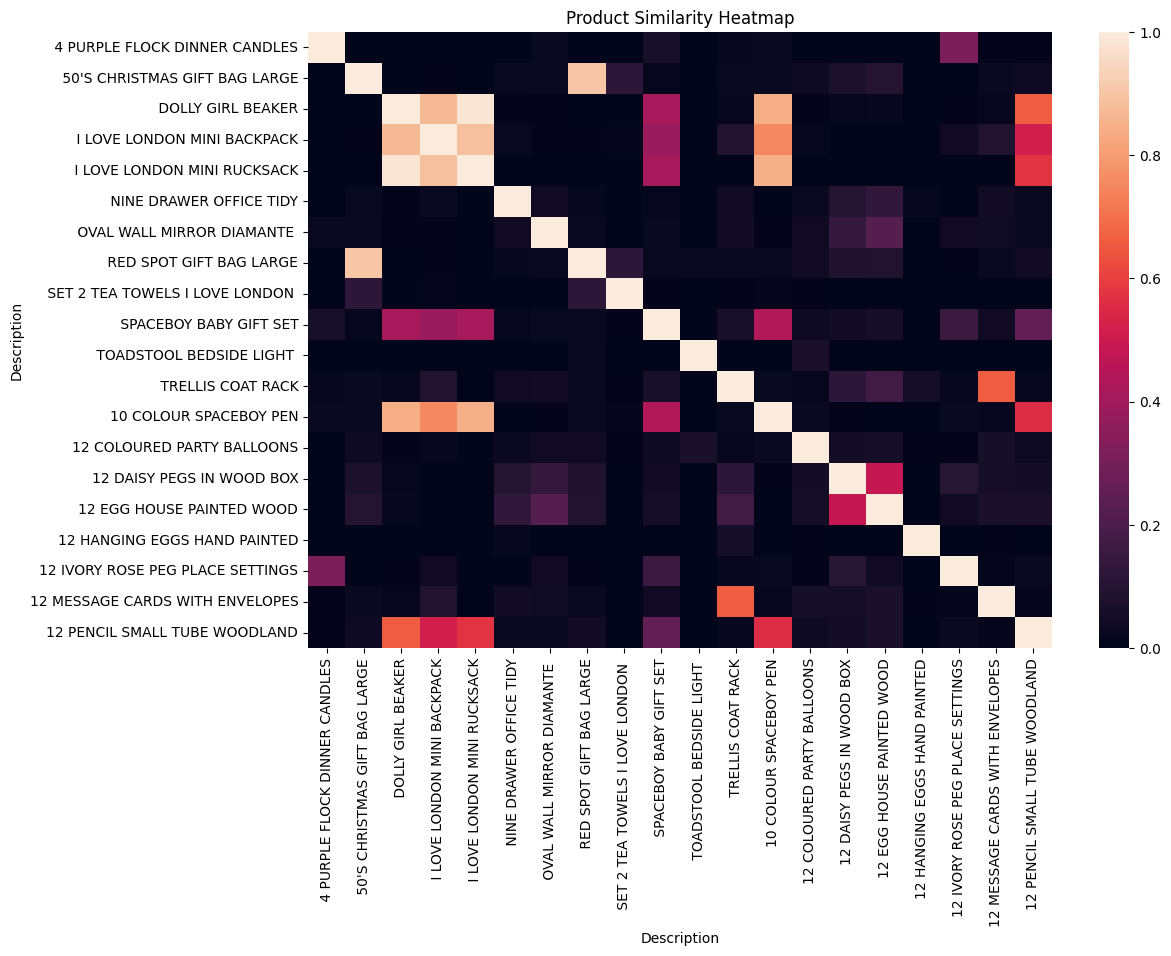

In [31]:
sample_products = similarity_df.iloc[:20,:20]

plt.figure(figsize=(12,8))

sns.heatmap(sample_products)

plt.title("Product Similarity Heatmap")

plt.show()

In [32]:
joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    similarity_df,
    "product_similarity.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


## Conclusion

This project analyzed e-commerce transaction data to understand customer behavior and purchasing patterns. After cleaning and preprocessing the dataset, exploratory data analysis was performed to extract useful insights.

Customer segmentation was done using clustering techniques to group users based on their buying behavior such as frequency and spending. This helps in identifying high-value and low-engagement customers for better targeting.

A basic recommendation analysis was also used to understand product relationships and improve personalized suggestions. The visualizations made it easier to interpret trends and patterns in sales and customer distribution.

Overall, the project shows how data science techniques can be applied in e-commerce to improve customer understanding, personalization, and business decision-making.

## Future Scope

In the future, this project can be enhanced by using more advanced machine learning algorithms for customer segmentation, such as hierarchical clustering or DBSCAN, to improve accuracy. The recommendation system can also be upgraded to collaborative filtering or hybrid recommendation models for more personalized and accurate product suggestions.

Real-time data integration can be added to analyze live customer behavior and dynamic purchasing trends. The dashboard can be further improved by deploying it on cloud platforms for wider accessibility. Additionally, incorporating deep learning techniques and customer sentiment analysis from reviews can provide deeper insights into customer preferences and improve business decision-making.